# 05 — Natural Experiments: Same Crop, Different Earth

Three crops appear in multiple RSUs with different climates and soils:

| Food | RSUs | Soil types |
|------|------|------------|
| Rice | RSU-06, RSU-11, RSU-12 | loess / laterite / volcanic |
| Potato | RSU-05, RSU-10 | loess / andean volcanic |
| Cassava | RSU-08, RSU-09 | laterite / tropical alluvial |

**Question:** Does the same crop have a different metabolite profile when grown in a different environment?

This is the cleanest test of H2 (soil amplification) — no distance matrix, no sparsity problem.
Just: same food, same measurement, different place.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rsu_loader import load_all_rsus, parse_numeric_ranges

NATURAL_EXPERIMENTS = {
    'potato':  ['RSU-05', 'RSU-10'],
    'rice':    ['RSU-06', 'RSU-11', 'RSU-12'],
    'cassava': ['RSU-08', 'RSU-09'],
}

MACRO_DIMS = [
    'primary_metabolites.protein_content',
    'primary_metabolites.lipid_content',
    'primary_metabolites.starch_content',
]

In [2]:
rsus = load_all_rsus()
ranges = parse_numeric_ranges(rsus)

# Environmental context per RSU
env_map = {r.region_id: {
    'name': r.name,
    'geology': r.geology.parent_material,
    'soil_pH': r.geology.soil_pH,
    'temp_mean': r.climate.temperature_mean,
    'precip_mean': r.climate.precipitation_mean,
    'lat': r.coordinates.lat,
} for r in rsus}

# Build flat records: one row per (food, RSU, dim)
records = []
for food_name, rsu_list in NATURAL_EXPERIMENTS.items():
    for rsu_id in rsu_list:
        dims = ranges.get(rsu_id, {}).get(food_name, {})
        for dim, (lo, hi) in dims.items():
            records.append({
                'food': food_name,
                'region_id': rsu_id,
                'dim': dim,
                'short_dim': dim.split('.')[-1],
                'value': (lo + hi) / 2,
                'lo': lo,
                'hi': hi,
                'is_macro': dim in MACRO_DIMS,
                **env_map[rsu_id],
            })

df = pd.DataFrame(records)

# Summary: which dims are shared across all RSUs for each food
print("Shared dimensions per natural experiment:")
for food_name, rsu_list in NATURAL_EXPERIMENTS.items():
    sub = df[df['food'] == food_name]
    dim_coverage = sub.groupby('dim')['region_id'].nunique()
    shared = dim_coverage[dim_coverage == len(rsu_list)].index.tolist()
    geo_shared = [d for d in shared if d not in MACRO_DIMS]
    print(f"  {food_name} ({', '.join(rsu_list)}):")
    print(f"    all shared dims:  {[d.split('.')[-1] for d in shared]}")
    print(f"    geo dims shared:  {[d.split('.')[-1] for d in geo_shared]}")
    if not geo_shared:
        print(f"    >> ONLY MACROS — all values from FDC generic entry, no terroir signal")

Shared dimensions per natural experiment:
  potato (RSU-05, RSU-10):
    all shared dims:  ['citric_acid', 'malic_acid', 'lipid_content', 'protein_content', 'starch_content', 'glutamate']
    geo dims shared:  ['citric_acid', 'malic_acid', 'glutamate']
  rice (RSU-06, RSU-11, RSU-12):
    all shared dims:  ['lipid_content', 'protein_content', 'starch_content']
    geo dims shared:  []
    >> ONLY MACROS — all values from FDC generic entry, no terroir signal
  cassava (RSU-08, RSU-09):
    all shared dims:  ['lipid_content', 'protein_content', 'starch_content']
    geo dims shared:  []
    >> ONLY MACROS — all values from FDC generic entry, no terroir signal


## Potato: RSU-05 (Central Europe, loess) vs RSU-10 (Andean Highlands, volcanic)

The only natural experiment with real geo dims: citric acid, malic acid, glutamate.
Same crop. Very different climate and soil. Do the organic acids and umami signal differ?

In [3]:
potato = df[df['food'] == 'potato'].copy()
potato_geo = potato[~potato['is_macro']]

print("Potato — all measured dims:")
pivot = potato.pivot(index='dim', columns='region_id', values='value')
pivot['delta'] = pivot['RSU-10'] - pivot['RSU-05']
pivot['delta_pct'] = (pivot['delta'] / pivot['RSU-05'].abs() * 100).round(1)
print(pivot.round(4).to_string())

print("\nEnvironmental context:")
for rsu_id in ['RSU-05', 'RSU-10']:
    e = env_map[rsu_id]
    print(f"  {rsu_id} {e['name']}: geology={e['geology']}, pH={e['soil_pH']}, "
          f"temp={e['temp_mean']}°C, precip={e['precip_mean']}mm, lat={e['lat']}°")

Potato — all measured dims:
region_id                            RSU-05  RSU-10  delta  delta_pct
dim                                                                  
organic_acids.citric_acid             0.500   0.800   0.30       60.0
organic_acids.malic_acid              0.240   0.280   0.04       16.7
primary_metabolites.lipid_content     0.375   0.375   0.00        0.0
primary_metabolites.protein_content   1.578   1.578   0.00        0.0
primary_metabolites.starch_content   17.328  17.328   0.00        0.0
umami_compounds.glutamate             0.040   0.160   0.12      300.0

Environmental context:
  RSU-05 Central Europe: geology=sedimentary, pH=6.5, temp=9.0°C, precip=650mm, lat=51.0°
  RSU-10 Andean Highlands: geology=volcanic, pH=5.5, temp=8.0°C, precip=800mm, lat=-13.5°


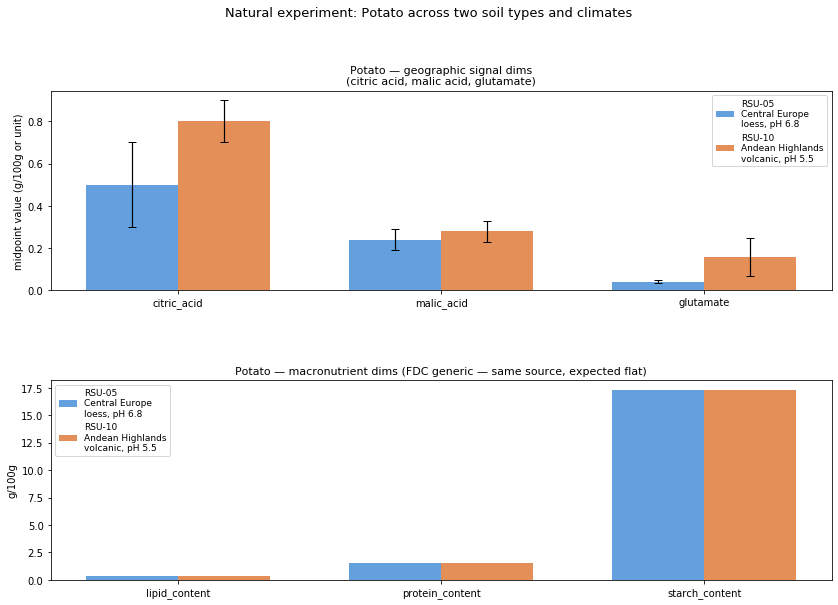

In [4]:
geo_dims_potato = sorted(potato_geo['dim'].unique())
macro_dims_potato = sorted(potato[potato['is_macro']]['dim'].unique())

rsu_colors = {'RSU-05': '#4a90d9', 'RSU-10': '#e07b39'}
rsu_labels = {
    'RSU-05': 'RSU-05\nCentral Europe\nloess, pH 6.8',
    'RSU-10': 'RSU-10\nAndean Highlands\nvolcanic, pH 5.5',
}

fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Top row: geo dims (the interesting ones)
ax_geo = fig.add_subplot(gs[0, :])
x = np.arange(len(geo_dims_potato))
width = 0.35
for k, rsu_id in enumerate(['RSU-05', 'RSU-10']):
    vals = [potato_geo[(potato_geo['dim'] == d) & (potato_geo['region_id'] == rsu_id)]['value'].values[0]
            for d in geo_dims_potato]
    los  = [potato_geo[(potato_geo['dim'] == d) & (potato_geo['region_id'] == rsu_id)]['lo'].values[0]
            for d in geo_dims_potato]
    his  = [potato_geo[(potato_geo['dim'] == d) & (potato_geo['region_id'] == rsu_id)]['hi'].values[0]
            for d in geo_dims_potato]
    errs = [[v - l for v, l in zip(vals, los)], [h - v for v, h in zip(vals, his)]]
    bars = ax_geo.bar(x + k * width, vals, width, label=rsu_labels[rsu_id],
                      color=rsu_colors[rsu_id], alpha=0.85)
    ax_geo.errorbar(x + k * width, vals, yerr=errs, fmt='none', color='black', capsize=4, lw=1.2)

ax_geo.set_xticks(x + width / 2)
ax_geo.set_xticklabels([d.split('.')[-1] for d in geo_dims_potato], fontsize=10)
ax_geo.set_ylabel('midpoint value (g/100g or unit)')
ax_geo.set_title('Potato — geographic signal dims\n(citric acid, malic acid, glutamate)', fontsize=11)
ax_geo.legend(fontsize=9)
ax_geo.axhline(0, color='gray', lw=0.5)

# Bottom row: macros (expected to be similar — same FDC source)
ax_mac = fig.add_subplot(gs[1, :])
x2 = np.arange(len(macro_dims_potato))
for k, rsu_id in enumerate(['RSU-05', 'RSU-10']):
    vals = [potato[(potato['dim'] == d) & (potato['region_id'] == rsu_id)]['value'].values[0]
            for d in macro_dims_potato]
    ax_mac.bar(x2 + k * width, vals, width, label=rsu_labels[rsu_id],
               color=rsu_colors[rsu_id], alpha=0.85)

ax_mac.set_xticks(x2 + width / 2)
ax_mac.set_xticklabels([d.split('.')[-1] for d in macro_dims_potato], fontsize=10)
ax_mac.set_ylabel('g/100g')
ax_mac.set_title('Potato — macronutrient dims (FDC generic — same source, expected flat)', fontsize=11)
ax_mac.legend(fontsize=9)

plt.suptitle('Natural experiment: Potato across two soil types and climates', fontsize=13, y=1.01)
plt.savefig('../data/metabolites/natural_exp_potato.png', dpi=150, bbox_inches='tight')
plt.show()

## Rice: RSU-06 / RSU-11 / RSU-12 — loess / laterite / volcanic

All three use the same FDC entry (2512381). Macros are identical by construction.
This is a data gap — FDC doesn't capture terroir. Shown here to make the gap explicit.

Rice — all measured dims:
region_id                            RSU-06  RSU-11  RSU-12
dim                                                        
primary_metabolites.lipid_content     1.033   1.033   1.033
primary_metabolites.protein_content   7.039   7.039   7.039
primary_metabolites.starch_content   80.313  80.313  80.313

Environmental context:
  RSU-06 East Asian Temperate: geology=sedimentary, pH=6.8, temp=13.0°C, precip=800mm
  RSU-11 South Indian Monsoon: geology=metamorphic, pH=6.0, temp=27.0°C, precip=1400mm
  RSU-12 Maritime Southeast Asia: geology=volcanic, pH=5.5, temp=27.5°C, precip=2800mm

>> All three RSUs share fdc_id=2512381. Identical values = no terroir signal captured.
   To test H2 for rice: need terroir-specific measurements (e.g. mineral content, aroma compounds by growing region).


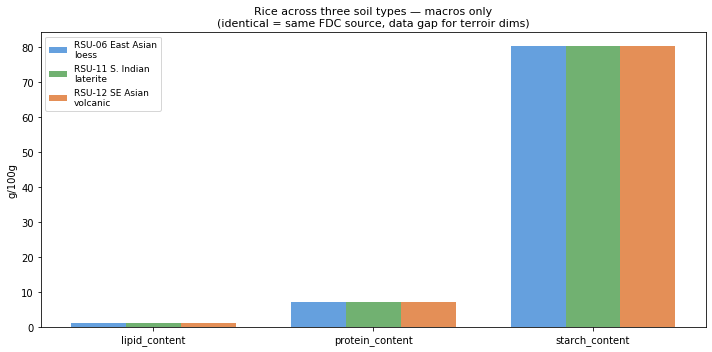

In [5]:
rice = df[df['food'] == 'rice'].copy()

print("Rice — all measured dims:")
pivot_rice = rice.pivot(index='dim', columns='region_id', values='value').round(4)
print(pivot_rice.to_string())

print("\nEnvironmental context:")
for rsu_id in ['RSU-06', 'RSU-11', 'RSU-12']:
    e = env_map[rsu_id]
    print(f"  {rsu_id} {e['name']}: geology={e['geology']}, pH={e['soil_pH']}, "
          f"temp={e['temp_mean']}°C, precip={e['precip_mean']}mm")

print("\n>> All three RSUs share fdc_id=2512381. Identical values = no terroir signal captured.")
print("   To test H2 for rice: need terroir-specific measurements (e.g. mineral content, aroma compounds by growing region).")

rsu_colors_rice = {'RSU-06': '#4a90d9', 'RSU-11': '#58a458', 'RSU-12': '#e07b39'}
rsu_labels_rice = {
    'RSU-06': 'RSU-06 East Asian\nloess',
    'RSU-11': 'RSU-11 S. Indian\nlaterite',
    'RSU-12': 'RSU-12 SE Asian\nvolcanic',
}

dims_rice = sorted(rice['dim'].unique())
x = np.arange(len(dims_rice))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for k, rsu_id in enumerate(['RSU-06', 'RSU-11', 'RSU-12']):
    vals = [rice[(rice['dim'] == d) & (rice['region_id'] == rsu_id)]['value'].values[0]
            for d in dims_rice]
    ax.bar(x + k * width, vals, width, label=rsu_labels_rice[rsu_id],
           color=rsu_colors_rice[rsu_id], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([d.split('.')[-1] for d in dims_rice], fontsize=10)
ax.set_ylabel('g/100g')
ax.set_title('Rice across three soil types — macros only\n(identical = same FDC source, data gap for terroir dims)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/metabolites/natural_exp_rice.png', dpi=150, bbox_inches='tight')
plt.show()

## Cassava: RSU-08 / RSU-09 — laterite / tropical alluvial

Same situation as rice — macros only from FDC. Shown for completeness.

In [6]:
cassava = df[df['food'] == 'cassava'].copy()

print("Cassava — all measured dims:")
pivot_cassava = cassava.pivot(index='dim', columns='region_id', values='value').round(4)
print(pivot_cassava.to_string())

print("\nEnvironmental context:")
for rsu_id in ['RSU-08', 'RSU-09']:
    e = env_map[rsu_id]
    print(f"  {rsu_id} {e['name']}: geology={e['geology']}, pH={e['soil_pH']}, "
          f"temp={e['temp_mean']}°C, precip={e['precip_mean']}mm")

print("\n>> Both RSUs share same FDC cassava entry. No terroir dims measured.")
print("   Cassava HCN (cyanogenic glucoside) content varies strongly by soil — a priority measurement for v0.3.")

Cassava — all measured dims:
region_id                            RSU-08  RSU-09
dim                                                
primary_metabolites.lipid_content     0.494   0.494
primary_metabolites.protein_content   0.918   0.918
primary_metabolites.starch_content   87.313  87.313

Environmental context:
  RSU-08 West African Transition Zone: geology=metamorphic, pH=5.8, temp=27.0°C, precip=1200mm
  RSU-09 Amazon Basin: geology=sedimentary, pH=4.5, temp=26.0°C, precip=2400mm

>> Both RSUs share same FDC cassava entry. No terroir dims measured.
   Cassava HCN (cyanogenic glucoside) content varies strongly by soil — a priority measurement for v0.3.


## Data gap summary — what to measure next

The natural experiments expose exactly where the data needs to grow.

In [7]:
gaps = [
    ('rice',    'RSU-06/11/12', 'aroma compounds (2-acetyl-1-pyrroline), mineral content by growing region'),
    ('rice',    'RSU-06/11/12', 'anthocyanins (red/black rice varieties specific to RSU-11/12)'),
    ('cassava', 'RSU-08/09',    'cyanogenic glucosides (HCN) — varies strongly with soil nitrogen and stress'),
    ('cassava', 'RSU-08/09',    'starch granule structure — differs by growing altitude and temperature'),
    ('potato',  'RSU-05/10',    'glycoalkaloids (solanine) — elevated in Andean high-altitude varieties'),
    ('potato',  'RSU-05/10',    'anthocyanins — purple Andean varieties vs European white'),
]

gaps_df = pd.DataFrame(gaps, columns=['food', 'rsus', 'missing_measurement'])
print("Priority measurements for natural experiment completion:")
print(gaps_df.to_string(index=False))

Priority measurements for natural experiment completion:
   food         rsus                                                         missing_measurement
   rice RSU-06/11/12   aroma compounds (2-acetyl-1-pyrroline), mineral content by growing region
   rice RSU-06/11/12               anthocyanins (red/black rice varieties specific to RSU-11/12)
cassava    RSU-08/09 cyanogenic glucosides (HCN) — varies strongly with soil nitrogen and stress
cassava    RSU-08/09      starch granule structure — differs by growing altitude and temperature
 potato    RSU-05/10      glycoalkaloids (solanine) — elevated in Andean high-altitude varieties
 potato    RSU-05/10                    anthocyanins — purple Andean varieties vs European white
